# Business Problem Analysis

## Workspace Initialization

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../data/raw/ecommerce_customer_churn_dataset.csv')
df.shape

(50000, 25)

In [3]:
df.columns

Index(['Age', 'Gender', 'Country', 'City', 'Membership_Years',
       'Login_Frequency', 'Session_Duration_Avg', 'Pages_Per_Session',
       'Cart_Abandonment_Rate', 'Wishlist_Items', 'Total_Purchases',
       'Average_Order_Value', 'Days_Since_Last_Purchase',
       'Discount_Usage_Rate', 'Returns_Rate', 'Email_Open_Rate',
       'Customer_Service_Calls', 'Product_Reviews_Written',
       'Social_Media_Engagement_Score', 'Mobile_App_Usage',
       'Payment_Method_Diversity', 'Lifetime_Value', 'Credit_Balance',
       'Churned', 'Signup_Quarter'],
      dtype='object')

In [33]:
# Drop invalid data records.

df = df[df['Age'] > 0]
df = df[df['Total_Purchases'] >= 0]
df = df[df['Lifetime_Value'] > 0]
df = df[df['Membership_Years'] <= df['Age']]

In [12]:
df.shape

(50000, 25)

---
## Statistical Properties

In [4]:
df['Churned'].value_counts()

Churned
0    35550
1    14450
Name: count, dtype: int64

In [5]:
df['Lifetime_Value'].describe()

count    50000.000000
mean      1440.626292
std        907.249443
min          0.000000
25%        789.817500
50%       1243.415000
75%       1874.000000
max       8987.240000
Name: Lifetime_Value, dtype: float64

## Visual Plots

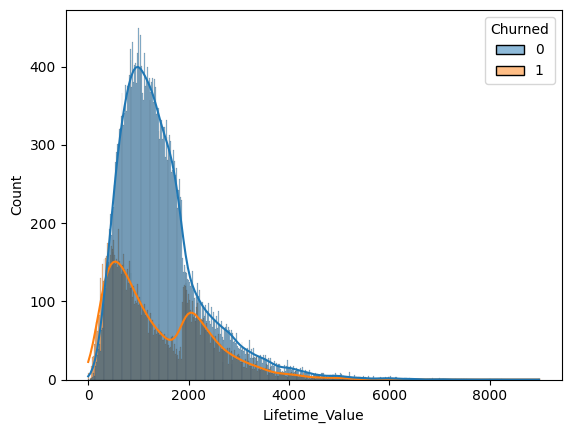

In [32]:
sns.histplot(df, x = 'Lifetime_Value', hue = 'Churned', kde=True, bins=500)
plt.show()

C:\Users\Monika\AppData\Local\Temp\ipykernel_8912\4209899364.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_rate = df.groupby('LTV_Segment')['Churned'].mean() * 100


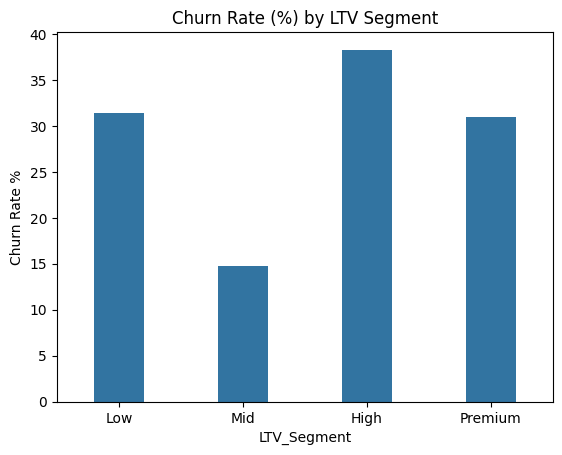

In [23]:
df['LTV_Segment'] = pd.cut(df['Lifetime_Value'],
                            bins=[0, 1200, 1800, 3500, float('inf')],
                            labels=['Low', 'Mid', 'High', 'Premium'])
churn_rate = df.groupby('LTV_Segment')['Churned'].mean() * 100

sns.barplot(churn_rate, width=0.4)
plt.title('Churn Rate (%) by LTV Segment')
plt.ylabel('Churn Rate %')
plt.xticks(rotation=0)
plt.show()

C:\Users\Monika\AppData\Local\Temp\ipykernel_8912\1622964200.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('LTV_Segment')['Churned']\


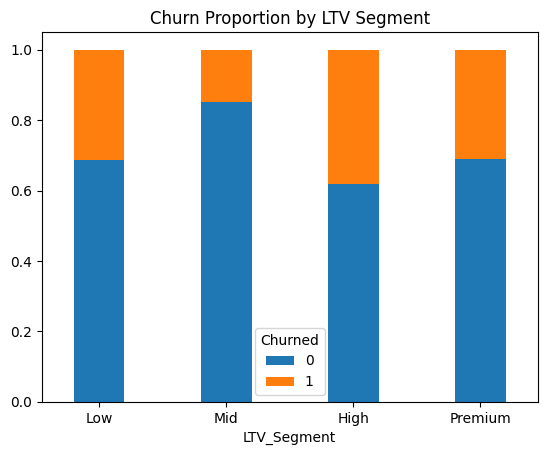

In [28]:
# seaborn doesn't support stack plot
df.groupby('LTV_Segment')['Churned']\
  .value_counts(normalize=True)\
  .unstack()\
  .plot(kind='bar', stacked=True, width=0.4)
plt.title('Churn Proportion by LTV Segment')
plt.xticks(rotation=0)
plt.show()

---
## Conclusion

**Customer Attrition by LTV Segment:**
* Low segment (~32% attrition) — high in volume but low in revenue impact, lower priority for intervention.
* Mid segment (~15% attrition) — most retained, lowest risk.
* High segment (~38% attrition) — significant risk, high revenue impact.
* Premium segment (~38% attrition) — most alarming, highest revenue impact per customer lost.

**Business Implication:**
Attrition is not uniform — the most valuable customers are leaving at the highest rate, 
making this a revenue risk, not just a volume problem.

**Modeling Targets Defined:**
* `Churned` → binary classification to identify at-risk customers.
* `Lifetime_Value` → regression to estimate customer worth before intervention.

**Modeling Strategy:**
Missing attrition in Low segment is acceptable. False alarms on High/Premium customers 
are tolerable — retaining them further only adds value. What the model must avoid is 
missing High/Premium customers who are about to leave.